##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

Model loaded successfully!
Loaded 5 images
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


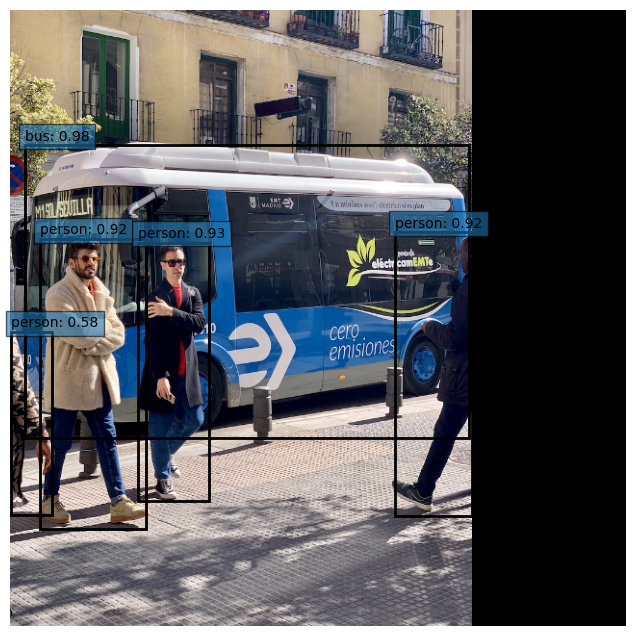

Image 1 detections:
  bus: 0.98
  person: 0.93
  person: 0.92
  person: 0.92
  person: 0.58
----------------------------------------


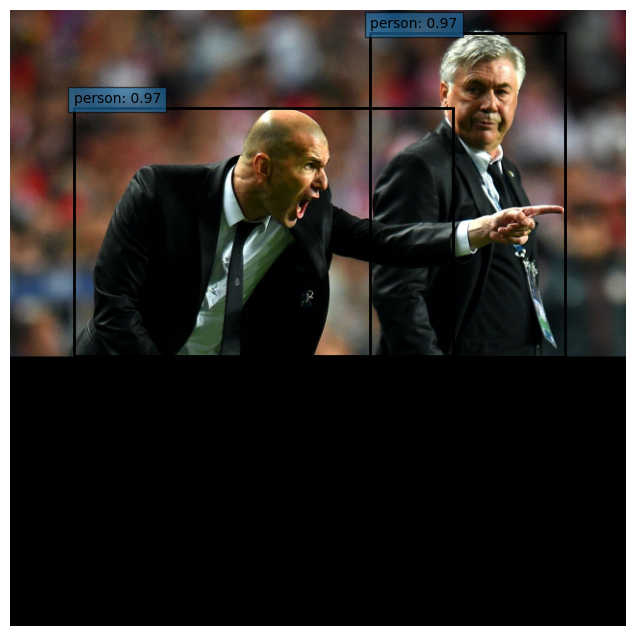

Image 2 detections:
  person: 0.97
  person: 0.97
----------------------------------------


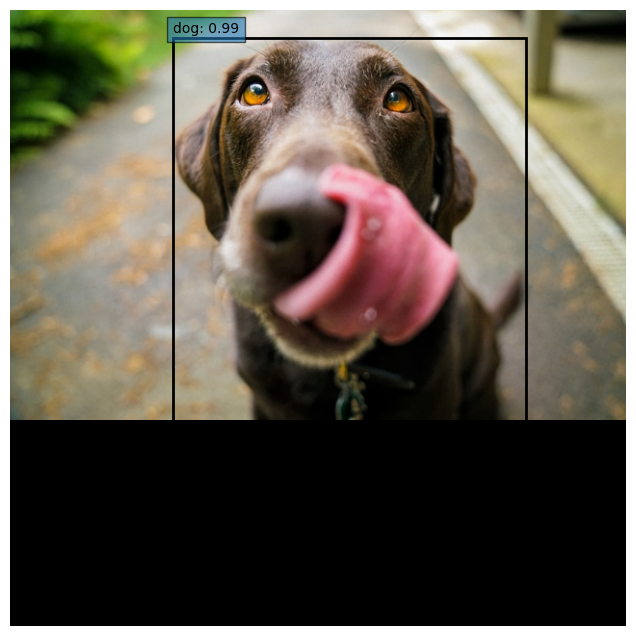

Image 3 detections:
  dog: 0.99
----------------------------------------


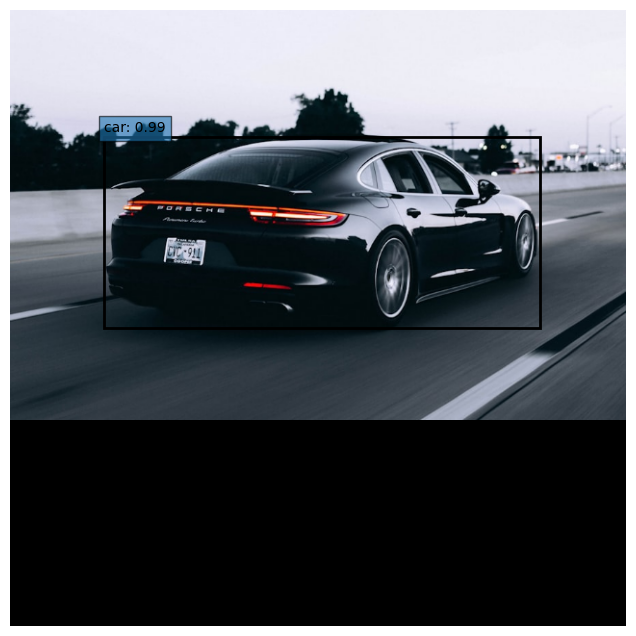

Image 4 detections:
  car: 0.99
----------------------------------------


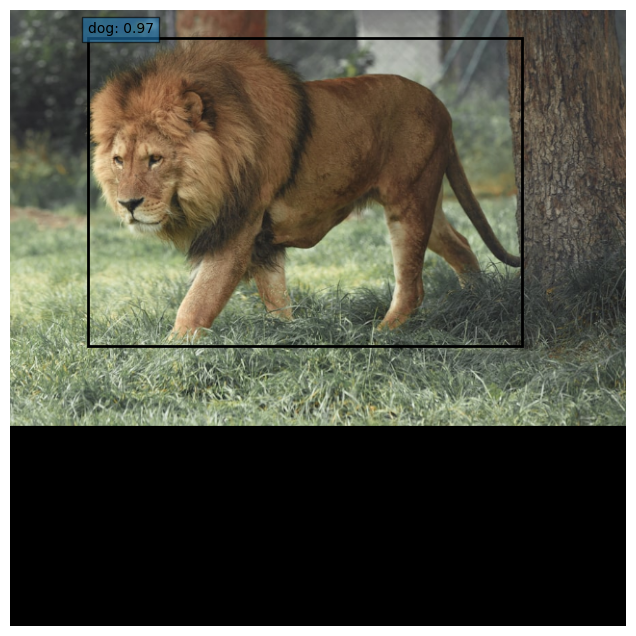

Image 5 detections:
  dog: 0.97
----------------------------------------


In [3]:
!pip install -q keras-cv

import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1) Load YOLOv8 Pascal VOC model
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

print("Model loaded successfully!")

# 2) Pascal VOC class names
class_names = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

# 3) Use reliable image URLs
image_urls = [
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    "https://images.unsplash.com/photo-1518717758536-85ae29035b6d?auto=format&fit=crop&w=900&q=80",
    "https://images.unsplash.com/photo-1503376780353-7e6692767b70?auto=format&fit=crop&w=900&q=80",
    "https://images.unsplash.com/photo-1546182990-dffeafbe841d?auto=format&fit=crop&w=900&q=80"
]

# 4) Resizing layer required by the exercise
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# 5) Load and resize each image separately
original_images = []
resized_images = []

for url in image_urls:
    response = requests.get(url, timeout=20)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = np.array(img)

    original_images.append(img)

    # resize one image at a time
    resized = inference_resizing(tf.convert_to_tensor(img, dtype=tf.float32))
    resized_images.append(resized)

# stack into one batch: (5, 640, 640, 3)
resized_images = tf.stack(resized_images, axis=0)

print("Loaded", len(original_images), "images")

# 6) Predict
predictions = model.predict(resized_images)

# 7) Visualization
def visualize(image, boxes, classes, scores, score_threshold=0.4):
    plt.figure(figsize=(8, 8))
    plt.imshow(image.astype("uint8"))
    ax = plt.gca()

    for box, cls, score in zip(boxes, classes, scores):
        if score < score_threshold:
            continue

        x, y, w, h = box
        x, y, w, h = float(x), float(y), float(w), float(h)

        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
        ax.add_patch(rect)

        cls = int(cls)
        label = class_names[cls] if 0 <= cls < len(class_names) else f"class {cls}"

        ax.text(
            x,
            y - 5 if y > 10 else y + 15,
            f"{label}: {score:.2f}",
            fontsize=10,
            bbox=dict(alpha=0.6)
        )

    plt.axis("off")
    plt.show()

# 8) Show results for each image
for i in range(len(original_images)):
    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    scores = predictions["confidence"][i]

    visualize(resized_images[i].numpy(), boxes, classes, scores)

    print(f"Image {i+1} detections:")
    for cls, score in zip(classes, scores):
        if score >= 0.4:
            cls = int(cls)
            label = class_names[cls] if 0 <= cls < len(class_names) else f"class {cls}"
            print(f"  {label}: {float(score):.2f}")
    print("-" * 40)